# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

#### Business Objectives

##### Background
The used car market is competitive and dynamic. Dealerships must optimize their inventory by acquiring vehicles that consumers value and pricing them accurately to ensure quick turnover and maximize profitability.

##### Business Goal
Identify the primary drivers of used car prices. Specifically, determine which attributes (e.g., mileage, age, brand, fuel type) command a premium.

##### Business Success Criteria
Provide clear, actionable recommendations to the dealership's inventory acquisition team regarding which vehicle types, brands, and specifications to stock and how to estimate their market value.

#### Data Mining Goals

Use supervised machine learning to train multiple regression models using cross-validation and hyperparameter grid searches with the goal of minimizing error metrics (MAE, RMSE). The goal is to identify coefficients and feature importance of the various quantitative features (e.g., `year`, `odometer`) and categorical features (e.g., `manufacturer`, `model`, `condition`, `fuel`, `transmission`, `type`) as it relates to the target variable (`price`).

Extract and interpret model coefficients and feature importances to quantify the impact of each feature on used car prices.


#### Project Plan

##### Data Understanding
Analyze features, visualize distributions, identify missing data, and detect outliers.

##### Data Preparation
Decide whether to impute or drop missing data, remove price and odometer outliers, perform feature engineering, and encode categorical variables.

##### Modeling
Build baseline and regularized regression models (Ridge/Lasso) with hyperparameter tuning.

##### Evaluation
Evaluate models using cross-validation, interpret coefficients, and check alignment with business goals.

##### Deployment
Present findings in a clear, non-technical summary report for the dealership management team.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

#### **Data Understanding Goals**
During this phase, we aim to familiarize ourselves with the dataset to identify quality issues and uncover preliminary insights that will inform our modeling. We will:
1. **Load and Profile the Dataset:** Check shape, data types, and basic structure.
2. **Assess Data Quality:** Quantify missing values, duplicate records, and identify structural inconsistencies.
3. **Analyze Descriptive Statistics:** Identify outliers, range of values, and potential errors (e.g., zero-priced cars).
4. **Perform Exploratory Data Analysis (EDA):** Use visualizations to examine relationships between continuous features (price, age, mileage) and categorical attributes (fuel type, transmission, manufacturer).

#### **Dataset Features Description**
* `id` / `VIN`: Unique identifiers (not predictive of price).
* `price` (Target): Resale price of the used car in USD.
* `year` / `odometer`: Age of the car and mileage (key continuous predictors).
* `manufacturer` / `model`: Brand and specific vehicle make.
* `condition` / `title_status` / `paint_color`: Qualitative assessments of vehicle state.
* `cylinders` / `fuel` / `transmission` / `drive` / `size` / `type`: Mechanical specifications of the car.
* `region` / `state`: Geographical variables indicating listing location.


In [11]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Load the dataset
df = pd.read_csv('data/vehicles.csv')

# Output shape and preview of types
print("Dataset Shape (Rows, Columns):", df.shape)
df.info()


Dataset Shape (Rows, Columns): (426880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  stat

#### **Interpretation of Shape and Schema**
* The dataset contains $426,880$ rows and $18$ columns. This is a substantial sample size, providing high statistical power for modeling.
* **Feature Types:**
  * **Numerical:** `price` (integer), `year` (float), `odometer` (float). Note that `year` should logically be treated as integer data.
  * **Categorical:** 14 columns are text-based (`object`), representing nominal features (e.g., `manufacturer`, `fuel`) and ordinal features (e.g., `condition`).
  * **Identifiers:** `id` and `VIN` are unique ID columns. `VIN` has a high cardinality and requires specific consideration.


In [13]:
# Calculate counts and percentages of missing values per column
missing_counts = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Consolidate into a data quality DataFrame
data_quality_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

print("=== Column Missing data Summary ===")
print(data_quality_df)

# Check for duplicate entries (excluding ID, which is always unique)
duplicate_count = df.duplicated(subset=df.columns.difference(['id'])).sum()
print(f"\nNumber of duplicate rows (excluding 'id'): {duplicate_count}")


=== Column Missing data Summary ===
              Missing Count  Percentage (%)
size                 306361       71.767476
cylinders            177678       41.622470
condition            174104       40.785232
VIN                  161042       37.725356
drive                130567       30.586347
paint_color          130203       30.501078
type                  92858       21.752717
manufacturer          17646        4.133714
title_status           8242        1.930753
model                  5277        1.236179
odometer               4400        1.030735
fuel                   3013        0.705819
transmission           2556        0.598763
year                   1205        0.282281
id                        0        0.000000
region                    0        0.000000
price                     0        0.000000
state                     0        0.000000

Number of duplicate rows (excluding 'id'): 56202


#### **Interpretation of Data Quality (Missing data and Integrity)**
* **High level of Missing data (>30%):**
Dropping rows with missing values in the columns below would result in losing a significant percentage of our dataset. We will either need robust imputation strategies (such as mode-imputation by vehicle type or grouping) or create a distinct `'missing'` indicator during data preparation. The `size` column should be dropped due to the very high percentage of missing values.
  * `size` (71.77% missing)
  * `cylinders` (41.62% missing)
  * `condition` (40.79% missing)
  * `VIN` (37.73% missing)
  * `drive` (30.59% missing)
  * `paint_color` (30.50% missing).

* **Low level of Missing data (<5%):**
The following features have minimal missing data. For these, simple imputation or dropping missing rows is acceptable.
  * `year` (0.28%)
  * `odometer` (1.03%)
  * `fuel` (0.71%)
  * `transmission` (0.60%)

* **Duplicates:** Excluding the unique id, there are $56,202$ duplicate rows. These will be retained for modeling as they represent identical vehicles listed multiple times, which is typical in auto listings.


In [14]:
# Standard numerical statistics
print("=== Summary Statistics for Numerical Columns ===")
print(df[['price', 'year', 'odometer']].describe().round(2))

# Investigate outliers and extreme values for price
print("\n=== Detailed Price Quantiles ===")
print(df['price'].quantile([0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0]).apply(lambda x: f"${x:,.2f}"))

# Investigate outliers and extreme values for odometer
print("\n=== Detailed Odometer Quantiles ===")
print(df['odometer'].quantile([0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0]).apply(lambda x: f"{x:,.1f} miles"))


=== Summary Statistics for Numerical Columns ===
              price       year     odometer
count  4.268800e+05  425675.00    422480.00
mean   7.519903e+04    2011.24     98043.33
std    1.218228e+07       9.45    213881.50
min    0.000000e+00    1900.00         0.00
25%    5.900000e+03    2008.00     37704.00
50%    1.395000e+04    2013.00     85548.00
75%    2.648575e+04    2017.00    133542.50
max    3.736929e+09    2022.00  10000000.00

=== Detailed Price Quantiles ===
0.000                $0.00
0.010                $0.00
0.050                $0.00
0.100              $500.00
0.250            $5,900.00
0.500           $13,950.00
0.750           $26,485.75
0.900           $37,590.00
0.950           $44,500.00
0.990           $66,995.00
0.999          $120,000.00
1.000    $3,736,928,711.00
Name: price, dtype: object

=== Detailed Odometer Quantiles ===
0.000             0.0 miles
0.010             2.0 miles
0.050         6,318.0 miles
0.100        14,939.0 miles
0.250        37,704.0

#### **Interpretation of Statistics and Anomalies**
* **Price Anomalies:** 
  * The median price is **$13,950** and the 75th percentile is **$26,485**. However, the minimum price is **$0** (representing at least 32,895 entries) and the maximum price is a staggering **$3,736,928,686**.
  * Listings with a price of $0 or token amounts (e.g., $1 or $5) represent incomplete postings, unpaid loans, or search optimization tags. On the upper end, prices above $100,000 contain data entry mistakes or extreme luxury collector cars. Both extremes will skew regression models and must be pruned.
* **Odometer Anomalies:**
  * The median mileage is **85,548 miles**. The maximum odometer reading is **10,000,000 miles**, which is an obvious typing error. The minimum is **0 miles**, which could represent new cars but also potential data issues.
* **Year Ranges:**
  * Listing years range from **1900 to 2022**. Classic cars usually follow a different pricing logic (valuing rarity and age) compared to modern used cars, which depreciate as they age. We should separate classic cars or restrict our model to modern consumer cars (post 1990).


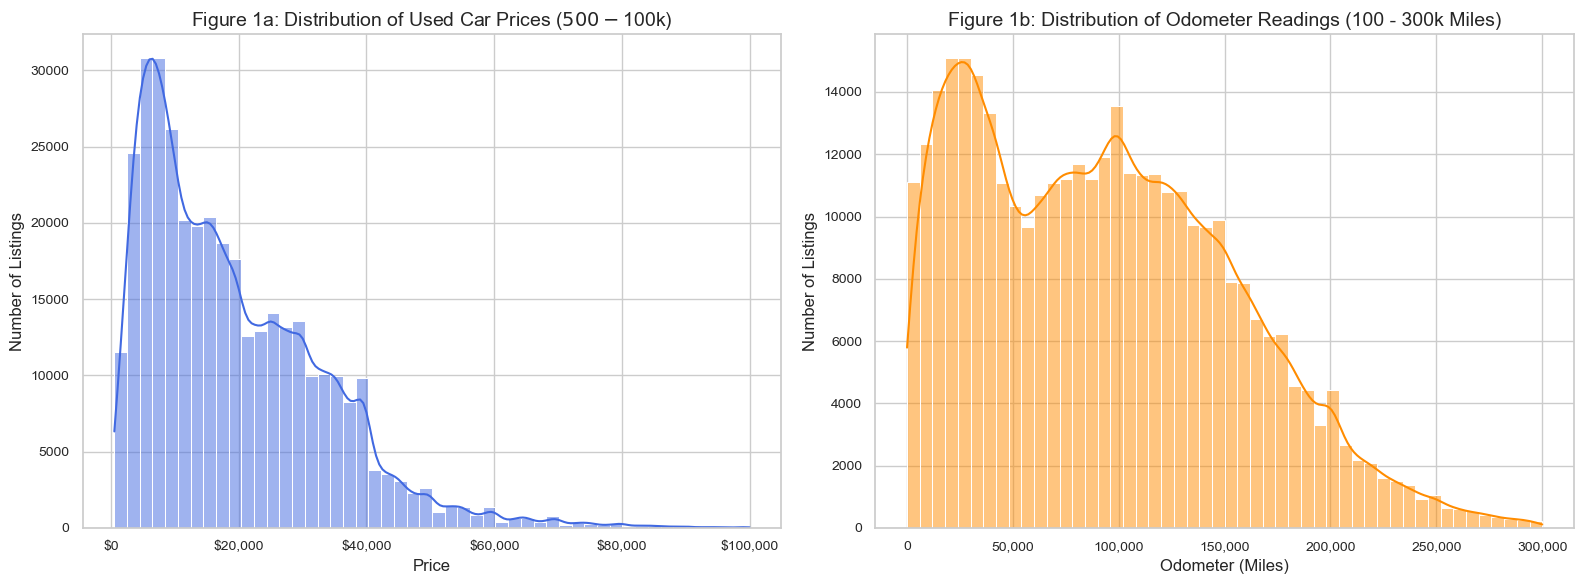

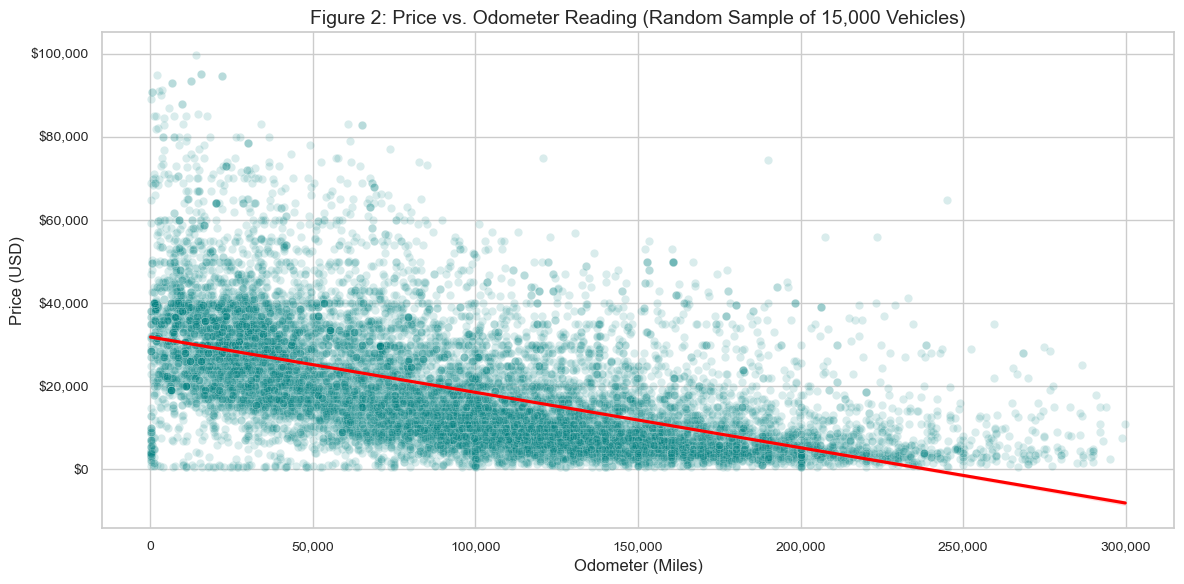

In [31]:
# Set visual theme for premium design, readability, and clean aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100
})

# Create a copy with realistic thresholds for visual analysis.
# remove price outliers
df_viz = df[(df['price'] > 500) & (df['price'] < 100000)].copy()
# remove odometer outliers
df_viz = df_viz[(df_viz['odometer'] > 100) & (df_viz['odometer'] < 300000)]
# remove classic cars
df_viz = df_viz[df_viz['year'] > 1990]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Distribution of Price
sns.histplot(df_viz['price'], bins=50, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Figure 1a: Distribution of Used Car Prices ($500 - $100k)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Number of Listings')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))

# Subplot 2: Distribution of Odometer
sns.histplot(df_viz['odometer'], bins=50, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Figure 1b: Distribution of Odometer Readings (100 - 300k Miles)')
axes[1].set_xlabel('Odometer (Miles)')
axes[1].set_ylabel('Number of Listings')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.tight_layout()
plt.show()

# Relationship between Price and Odometer (Sampled to restrict points plotted to a reasonable number)
df_sample = df_viz.sample(15000)
sns.scatterplot(data=df_sample, x='odometer', y='price', alpha=0.15, color='teal')
sns.regplot(data=df_sample, x='odometer', y='price', scatter=False, color='red')
plt.title('Figure 2: Price vs. Odometer Reading (Random Sample of 15,000 Vehicles)')
plt.xlabel('Odometer (Miles)')
plt.ylabel('Price (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y):,}"))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.tight_layout()
plt.show()


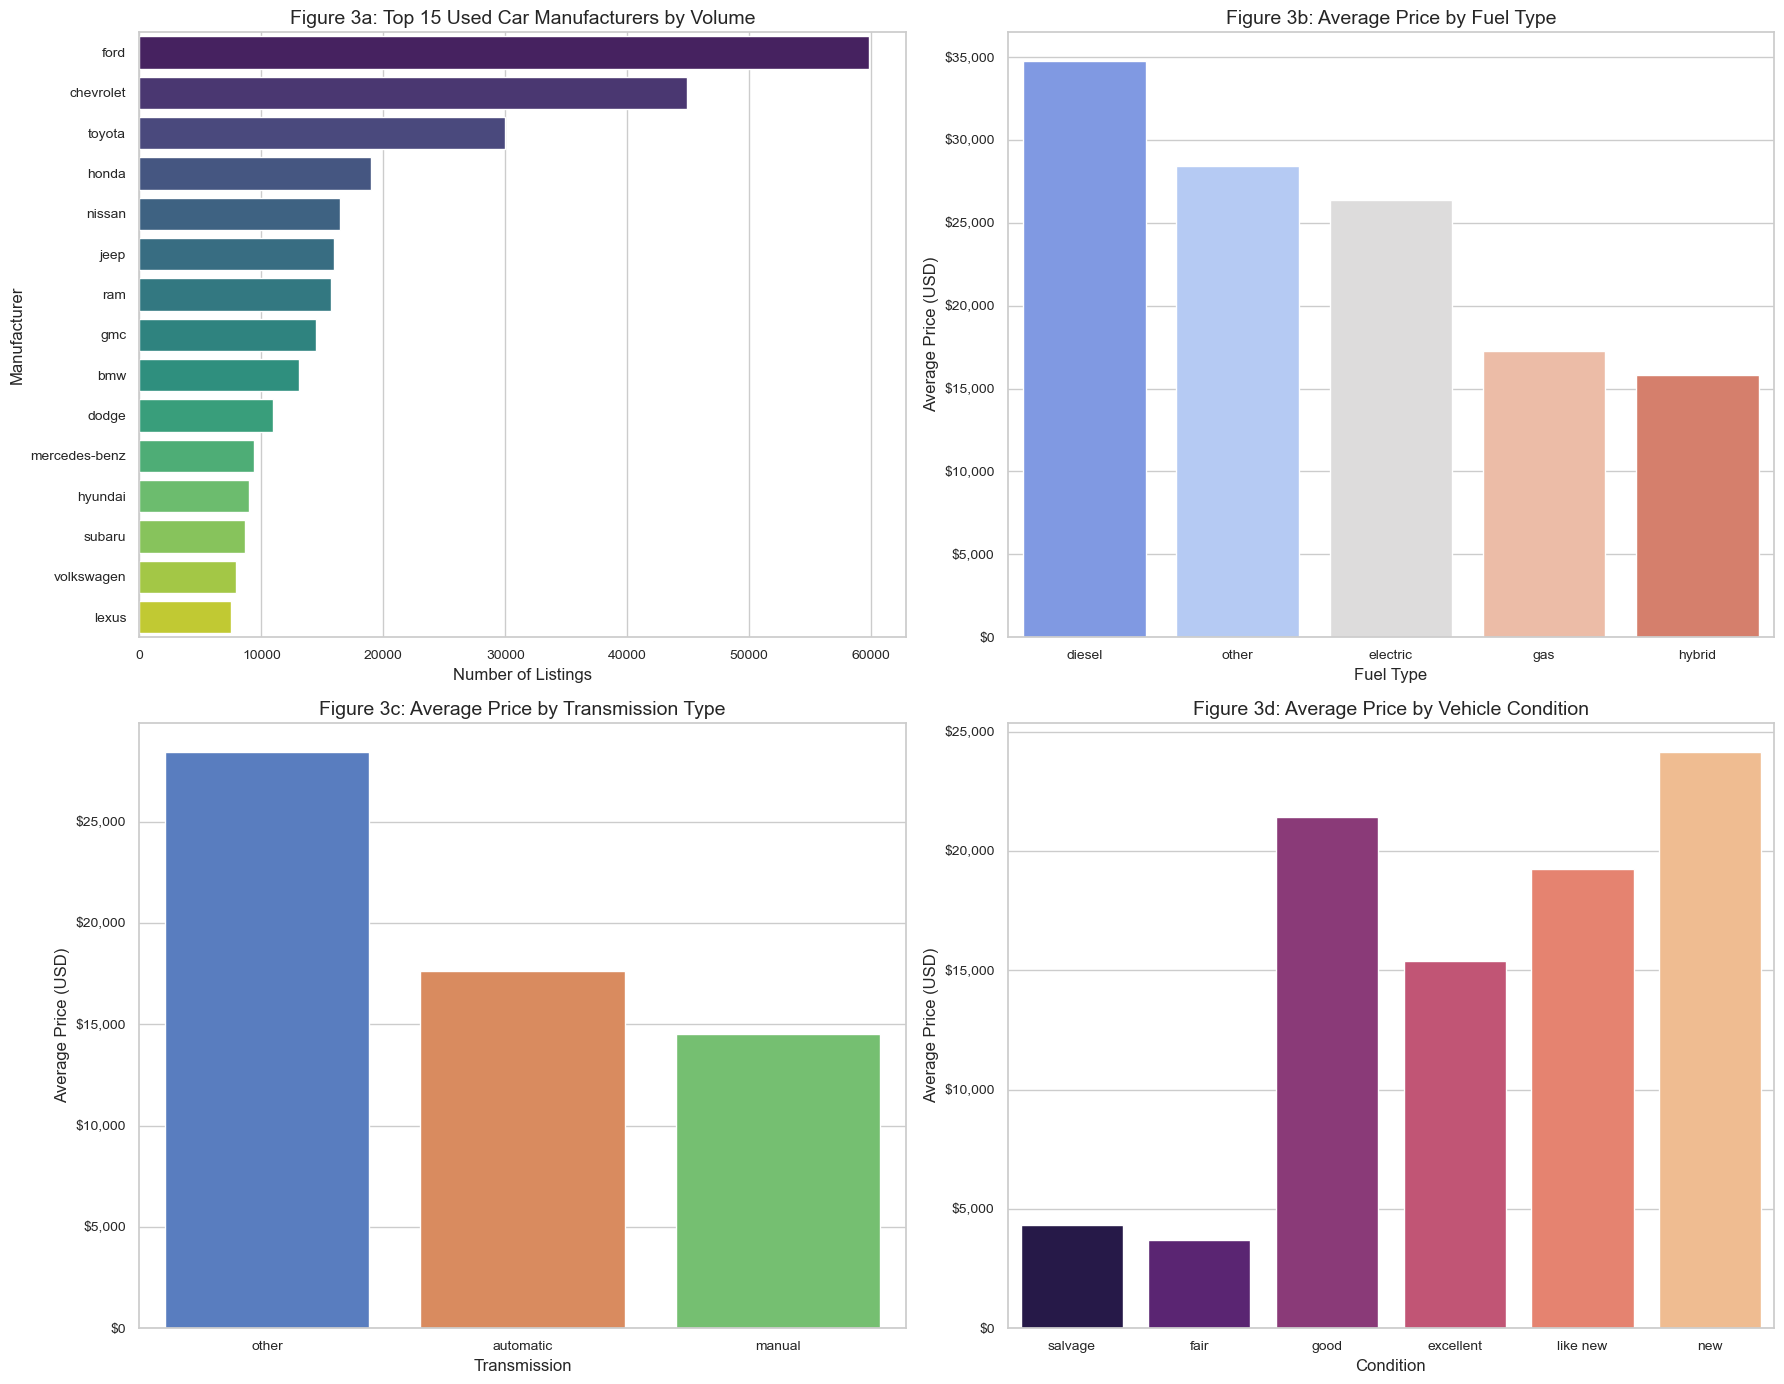

In [45]:
# Set up a 2x2 panel of categorical distributions and average prices
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top 15 Manufacturers by Listing Volume
top_manufacturers = df_viz['manufacturer'].value_counts().head(15).index
sns.countplot(data=df_viz[df_viz['manufacturer'].isin(top_manufacturers)],
              y='manufacturer',
              order=top_manufacturers,
              ax=axes[0, 0],
              palette='viridis',
              legend=False)
axes[0, 0].set_title('Figure 3a: Top 15 Used Car Manufacturers by Volume')
axes[0, 0].set_xlabel('Number of Listings')
axes[0, 0].set_ylabel('Manufacturer')

# Average Price by Fuel Type
avg_price_fuel = df_viz.groupby('fuel')['price'].mean().sort_values(ascending=False).index
sns.barplot(data=df_viz,
            x='fuel',
            y='price',
            ax=axes[0, 1],
            errorbar=None,
            order=avg_price_fuel,
            palette='coolwarm',
            legend=False)
axes[0, 1].set_title('Figure 3b: Average Price by Fuel Type')
axes[0, 1].set_xlabel('Fuel Type')
axes[0, 1].set_ylabel('Average Price (USD)')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y):,}"))

# Average Price by Transmission Type
avg_price_trans = df_viz.groupby('transmission')['price'].mean().sort_values(ascending=False).index
sns.barplot(data=df_viz, 
            x='transmission',
            y='price',
            ax=axes[1, 0],
            errorbar=None,
            order=avg_price_trans,
            hue='transmission',
            legend=False)
axes[1, 0].set_title('Figure 3c: Average Price by Transmission Type')
axes[1, 0].set_xlabel('Transmission')
axes[1, 0].set_ylabel('Average Price (USD)')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y):,}"))

# 4. Average Price by Condition
condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']
sns.barplot(data=df_viz,
            x='condition',
            y='price',
            ax=axes[1, 1],
            errorbar=None,
            order=condition_order,
            palette='magma',
            legend=False)
axes[1, 1].set_title('Figure 3d: Average Price by Vehicle Condition')
axes[1, 1].set_xlabel('Condition')
axes[1, 1].set_ylabel('Average Price (USD)')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"${int(y):,}"))

plt.tight_layout()
plt.show()


#### **EDA Interpretation**
1. **Price vs Mileage:** Figure 2 displays a clear, negative relationship showing that higher mileage (odometer) correlates with a decrease in vehicle price. This represents standard vehicle depreciation and will likely be a major coefficient in our modeling.
2. **Market Volume Dominance:** Ford and Chevrolet represent the highest number of listings. Our model will be highly influenced by their pricing structures.
3. **Premium Fuel Types:** Diesel vehicles command a significant average price premium over gas, hybrid, and electric vehicles (**Figure 3b**), indicating high resale value retention for work trucks and heavy-duty vehicles.
4. **Transmission Premium:** "Other" transmissions carry the highest average prices, whereas manual transmissions are the cheapest, reflecting their decline in modern consumer vehicles. (**Figure 3c**).
5. **Condition Grading:** Prices scale linearly with condition quality (salvage -> new), confirming that condition should be handled ordinally during encoding (**Figure 3d**).

#### **Data Preparation Action Items**
To ready the dataset for regression modeling, we must address the following issues identified during this phase:
1. **Filter Outliers:** Filter the dataset to include prices between `$500` and `$100,000`, odometer values between `100` and `300,000` miles, and registration years after `1990`.
2. **Feature Removal:** Drop irrelevant identifiers (`id`, `VIN`) and columns with excessive missingness (like `size` with 71.77% missing) to avoid sparse matrices.
3. **Imputation:** Apply mode-imputation or fill missing categorical slots with a new `'missing'` category to avoid dropping valuable rows.
4. **Encoding:** Apply one-hot encoding to low-cardinality categories (`fuel`, `transmission`, `condition`, `drive`) and target encoding or grouping for high-cardinality columns like `manufacturer` and `model`.


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

#### Data Preparation Goals & Strategy
During this phase, we clean and prepare our dataset for regression modeling. Based on our findings in the Data Understanding phase, we will implement the following steps:
1. **Outlier and Classic Car Filtering:** We restrict our dataset to listings with prices between `$500` and `$100,000`, odometer readings between `100` and `300,000` miles, and years after `1990` to remove junk data, classic car pricing dynamics, and obvious typos.
2. **Feature Pruning:** Drop unique identifiers (`id`, `VIN`) and columns with excessive missing data (`size` with 71.77% missing).
3. **Advanced Imputation:**
   - Drop rows with null values in features with very low missing data (<5%) to maintain maximum clean sample size.
   - Impute missing specifications (`cylinders`, `drive`, `type`) by calculating the most frequent category (mode) for each specific vehicle `model`.
   - Impute subjective categories like `paint_color` and `condition` with a `'missing'` placeholder, and fill `title_status` nulls with its global mode.
4. **Feature Engineering:** Calculate vehicle `age` from `year` (using $2021$ as the benchmark year) and drop the raw `year` column.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Reload the dataset to ensure a clean start
df = pd.read_csv('data/vehicles.csv')

# 1. Apply outlier filtering
df_cleaned = df[
    (df['price'] >= 500) & (df['price'] <= 100000) &
    (df['odometer'] >= 100) & (df['odometer'] <= 300000) &
    (df['year'] >= 1990)
].copy()

# 2. Drop unique identifiers and columns with excessive missingness
df_cleaned = df_cleaned.drop(columns=['id', 'VIN', 'size'])

# 3. Drop rows with null values in key columns with low missingness (<5%)
key_cols = ['year', 'odometer', 'fuel', 'transmission', 'manufacturer', 'model']
df_cleaned = df_cleaned.dropna(subset=key_cols)

# 4. Group-based Mode Imputation helper function
def impute_mode_by_group(df, target_col, group_col):
    # create counts dataframe for target_col, group_col pairs
    counts = df.groupby([group_col, target_col]).size().reset_index(name='count')
    sorted_counts = counts.sort_values([group_col, 'count'], ascending=[True, False])
    # mode_map contains the target_col mode for each group_col value
    mode_map = sorted_counts.drop_duplicates(subset=[group_col]).set_index(group_col)[target_col]
    
    # Global mode for group_col in case a model has no mode
    global_mode = df[target_col].mode()[0]

    imputed_vals = df[group_col].map(mode_map).fillna(global_mode)
    df[target_col] = df[target_col].fillna(imputed_vals)
    return df

df_cleaned = impute_mode_by_group(df_cleaned, 'cylinders', 'model')
df_cleaned = impute_mode_by_group(df_cleaned, 'drive', 'model')
df_cleaned = impute_mode_by_group(df_cleaned, 'type', 'model')

# Fill remaining categoricals with appropriate placeholders/modes
df_cleaned['paint_color'] = df_cleaned['paint_color'].fillna('missing')
df_cleaned['condition'] = df_cleaned['condition'].fillna('missing')
df_cleaned['title_status'] = df_cleaned['title_status'].fillna(df_cleaned['title_status'].mode()[0])

# 5. Feature Engineering: Vehicle Age
df_cleaned['age'] = 2021 - df_cleaned['year']
df_cleaned = df_cleaned.drop(columns=['year'])

print("Cleaned Dataset Shape:", df_cleaned.shape)
print("Missing Values Remaining:\n", df_cleaned.isnull().sum())

Cleaned Dataset Shape: (345436, 15)
Missing Values Remaining:
 region          0
price           0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
age             0
dtype: int64


#### Handling High-Cardinality & Preventing Data Leakage
Several nominal categorical features exhibit extremely high cardinality:
* `model`: ~19,600 unique values
* `region`: ~400 unique values
* `state`: 51 unique values
* `manufacturer`: 40 unique values

Using standard one-hot encoding on these features would generate over 20,000 columns, causing severe sparse-matrix dimensionality issues and out-of-memory errors.

To resolve this, we will use **Target Encoding** (mean encoding) for these four high-cardinality features. Each category is replaced with the mean target value (`price`) of that category.

**Critical Prevention of Data Leakage:**
To prevent target leakage, target encoding must be calculated **strictly using the training set (`y_train`)** and then mapped onto the test set. Any unseen category in the test set will be filled using the global training mean.

In [47]:
# Separate features and target
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

# Train-test split (70% train, 30% test) to prepare for target encoding
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Apply manual target encoding for high-cardinality variables
high_card_cols = ['model', 'manufacturer', 'region', 'state']

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

for col in high_card_cols:
    # Compute mean target value solely on the training set
    category_means = y_train.groupby(X_train[col]).mean()
    global_mean = y_train.mean()
    
    # Map to both training and test datasets
    X_train_encoded[col] = X_train_encoded[col].map(category_means).fillna(global_mean)
    X_test_encoded[col] = X_test_encoded[col].map(category_means).fillna(global_mean)

print("X_train shape after target encoding:", X_train_encoded.shape)
print("X_test shape after target encoding:", X_test_encoded.shape)

X_train shape after target encoding: (241805, 14)
X_test shape after target encoding: (103631, 14)


#### Feature Scaling and One-Hot Encoding
After converting high-cardinality variables into numerical target means, we assemble our preprocessing pipeline:
1. **Numerical Standardization (`StandardScaler`):** Applied to numerical features (`age`, `odometer`) and target-encoded features (`model`, `manufacturer`, `region`, `state`) to ensure models like Ridge and Lasso are regularized equitably.
2. **One-Hot Encoding (`OneHotEncoder`):** Applied to the remaining low-cardinality nominal and categorical features (`fuel`, `transmission`, `drive`, `type`, `paint_color`, `condition`, `title_status`, `cylinders`).

In [50]:
# Define continuous features (including target-encoded features)
num_features = ['age', 'odometer', 'model', 'manufacturer', 'region', 'state']

# Define categorical features for One-Hot Encoding
low_card_features = ['fuel', 'transmission', 'drive', 'type', 'paint_color', 'condition', 'title_status', 'cylinders']

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('low_card', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), low_card_features)
    ]
)

# Fit-transform train set and transform test set
X_train_processed = preprocessor.fit_transform(X_train_encoded)
X_test_processed = preprocessor.transform(X_test_encoded)

# Get feature names for interpretability later
feature_names = num_features + list(preprocessor.named_transformers_['low_card'].get_feature_names_out(low_card_features))

print("Final X_train processed dimensions (Rows, Features):", X_train_processed.shape)
print("Final X_test processed dimensions (Rows, Features):", X_test_processed.shape)
print("Number of engineered features:", len(feature_names))

Final X_train processed dimensions (Rows, Features): (241805, 56)
Final X_test processed dimensions (Rows, Features): (103631, 56)
Number of engineered features: 56


#### Data Preparation Summary
* **Sample Preservation:** Dropping entries listwise only for features with $<5\%$ missingness, coupled with group-mode imputation, preserved **$345,436$ rows** out of $426,880$ original listings (~$81\%$).
* **Feature Count:** Target encoding high-cardinality nominals kept the post-processed feature matrix size extremely efficient, containing only **56 dimensions** (features) compared to the $20,000+$ features we would have generated using standard One-Hot Encoding. This guarantees stable and rapid training in our **Modeling** phase.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.